# M3 Phase 1 - Explainability and Metrics Specialist

This notebook delivers:
- Evaluation metrics: Accuracy, Precision, Recall, F1-score
- Confusion matrix + heatmap export
- Grad-CAM pipeline on sample images
- Saved visual outputs for report
- Early training checkpoint feedback for M1


In [15]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [16]:
# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == 'phase1' else Path.cwd().resolve()
PHASE1_DIR = PROJECT_ROOT / 'Phase1'
BASE_DIR = Path(r'C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dataset')

METADATA_CANDIDATES = [
    BASE_DIR / 'metadata.csv',
    BASE_DIR / 'sample_metadata.csv',
]

CHECKPOINT_CANDIDATES = [
    PHASE1_DIR / 'models' / 'resnet18_subset_best.pt',
    PHASE1_DIR / 'cifake_resnet18_final.pt',
    BASE_DIR / 'models' / 'resnet18_subset_best.pt',
]

RESULTS_METRICS_DIR = PHASE1_DIR / 'results_metrics'
RESULTS_GRADCAM_DIR = PHASE1_DIR / 'results_gradcam'
RESULTS_METRICS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PHASE1_DIR: {PHASE1_DIR}")
print(f"BASE_DIR: {BASE_DIR}")
print(f"results_metrics: {RESULTS_METRICS_DIR}")
print(f"results_gradcam: {RESULTS_GRADCAM_DIR}")

PROJECT_ROOT: C:\Users\Vedha\feb hack\Feb-2026-Hackathon
PHASE1_DIR: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1
BASE_DIR: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dataset
results_metrics: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics
results_gradcam: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_gradcam


In [17]:
# Data utilities
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_WORKERS = 0
CLASS_NAMES = ['REAL', 'FAKE']
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2023, 0.1994, 0.2010]

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
])

def build_test_dataframe(base_dir: Path) -> pd.DataFrame:
    records = []
    test_root = base_dir / 'test'
    for label_name, label_id in [('REAL', 0), ('FAKE', 1)]:
        class_dir = test_root / label_name
        if not class_dir.exists():
            continue
        for p in class_dir.glob('*'):
            if p.is_file():
                records.append({
                    'filepath': str(p.relative_to(base_dir)).replace('\\', '/'),
                    'label': label_id,
                    'label_name': label_name,
                    'split': 'test',
                })
    return pd.DataFrame(records)

def load_metadata_for_test(base_dir: Path) -> pd.DataFrame:
    for meta_path in METADATA_CANDIDATES:
        if meta_path.exists():
            df = pd.read_csv(meta_path)
            if 'split' in df.columns:
                test_df = df[df['split'] == 'test'].copy()
            else:
                test_df = df.copy()
            if len(test_df) > 0:
                print(f"Using metadata file: {meta_path}")
                return test_df
    print('No metadata CSV found. Falling back to folder scan under test/.')
    return build_test_dataframe(base_dir)

class CIFAKETestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_dir / row['filepath']
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label, str(img_path)

meta_test_df = load_metadata_for_test(BASE_DIR)
print(f"Test rows: {len(meta_test_df):,}")
print(meta_test_df[['label']].value_counts())

test_ds = CIFAKETestDataset(meta_test_df, BASE_DIR, transform=transform_eval)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Test batches: {len(test_loader)}")

Using metadata file: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dataset\metadata.csv
Test rows: 20,000
label
0        10000
1        10000
Name: count, dtype: int64
Test batches: 157


In [18]:
# Model utilities

def build_resnet18(num_classes=2, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes),
    )
    return model

def find_checkpoint() -> Path:
    for p in CHECKPOINT_CANDIDATES:
        if p.exists():
            return p
    raise FileNotFoundError(
        'No checkpoint found. Expected one of: ' + ', '.join(str(p) for p in CHECKPOINT_CANDIDATES)
    )

ckpt_path = find_checkpoint()
print(f"Loading checkpoint: {ckpt_path}")

model = build_resnet18(num_classes=2, freeze_backbone=False)
checkpoint = torch.load(ckpt_path, map_location='cpu')

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=True)
model = model.to(device)
model.eval()
print('Model loaded successfully.')

Loading checkpoint: C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\models\resnet18_subset_best.pt
Model loaded successfully.


In [19]:
# Evaluation: accuracy, precision, recall, f1 + confusion matrix
all_preds = []
all_probs = []
all_labels = []
all_paths = []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_paths.extend(list(paths))

metrics = {
    'accuracy': accuracy_score(all_labels, all_preds),
    'precision': precision_score(all_labels, all_preds, zero_division=0),
    'recall': recall_score(all_labels, all_preds, zero_division=0),
    'f1_score': f1_score(all_labels, all_preds, zero_division=0),
}

metrics_df = pd.DataFrame([metrics])
metrics_csv = RESULTS_METRICS_DIR / 'metrics_summary.csv'
metrics_df.to_csv(metrics_csv, index=False)

print('Metrics summary:')
display(metrics_df)
print(f"Saved metrics summary -> {metrics_csv}")

report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
report_path = RESULTS_METRICS_DIR / 'classification_report.txt'
report_path.write_text(report_txt, encoding='utf-8')
print('Classification report:')
print(report_txt)
print(f"Saved classification report -> {report_path}")

preds_df = pd.DataFrame({
    'path': all_paths,
    'y_true': all_labels,
    'y_pred': all_preds,
    'p_fake': all_probs,
})
preds_csv = RESULTS_METRICS_DIR / 'test_predictions.csv'
preds_df.to_csv(preds_csv, index=False)
print(f"Saved per-image predictions -> {preds_csv}")

Metrics summary:


,accuracy,precision,recall,f1_score
0,0.67675,0.673098,0.6873,0.680125


Saved metrics summary -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\metrics_summary.csv
Classification report:
              precision    recall  f1-score   support

        REAL     0.6806    0.6662    0.6733     10000
        FAKE     0.6731    0.6873    0.6801     10000

    accuracy                         0.6767     20000
   macro avg     0.6768    0.6767    0.6767     20000
weighted avg     0.6768    0.6767    0.6767     20000

Saved classification report -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\classification_report.txt
Saved per-image predictions -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\test_predictions.csv


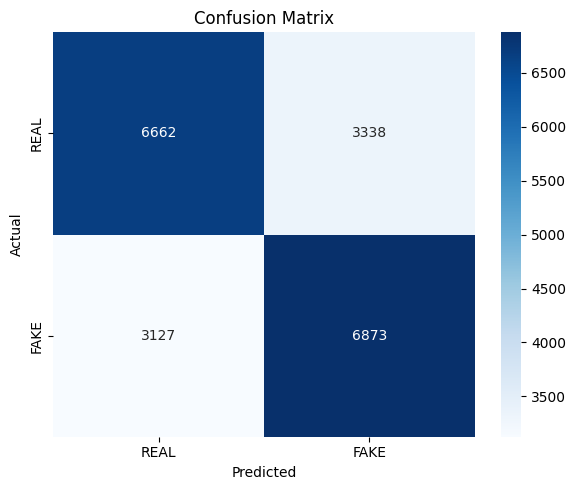

Saved confusion matrix table -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\confusion_matrix.csv
Saved confusion matrix heatmap -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\confusion_matrix_heatmap.png


In [20]:
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=[f'True_{c}' for c in CLASS_NAMES], columns=[f'Pred_{c}' for c in CLASS_NAMES])
cm_csv = RESULTS_METRICS_DIR / 'confusion_matrix.csv'
cm_df.to_csv(cm_csv)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
cm_png = RESULTS_METRICS_DIR / 'confusion_matrix_heatmap.png'
plt.savefig(cm_png, dpi=180)
plt.show()

print(f"Saved confusion matrix table -> {cm_csv}")
print(f"Saved confusion matrix heatmap -> {cm_png}")

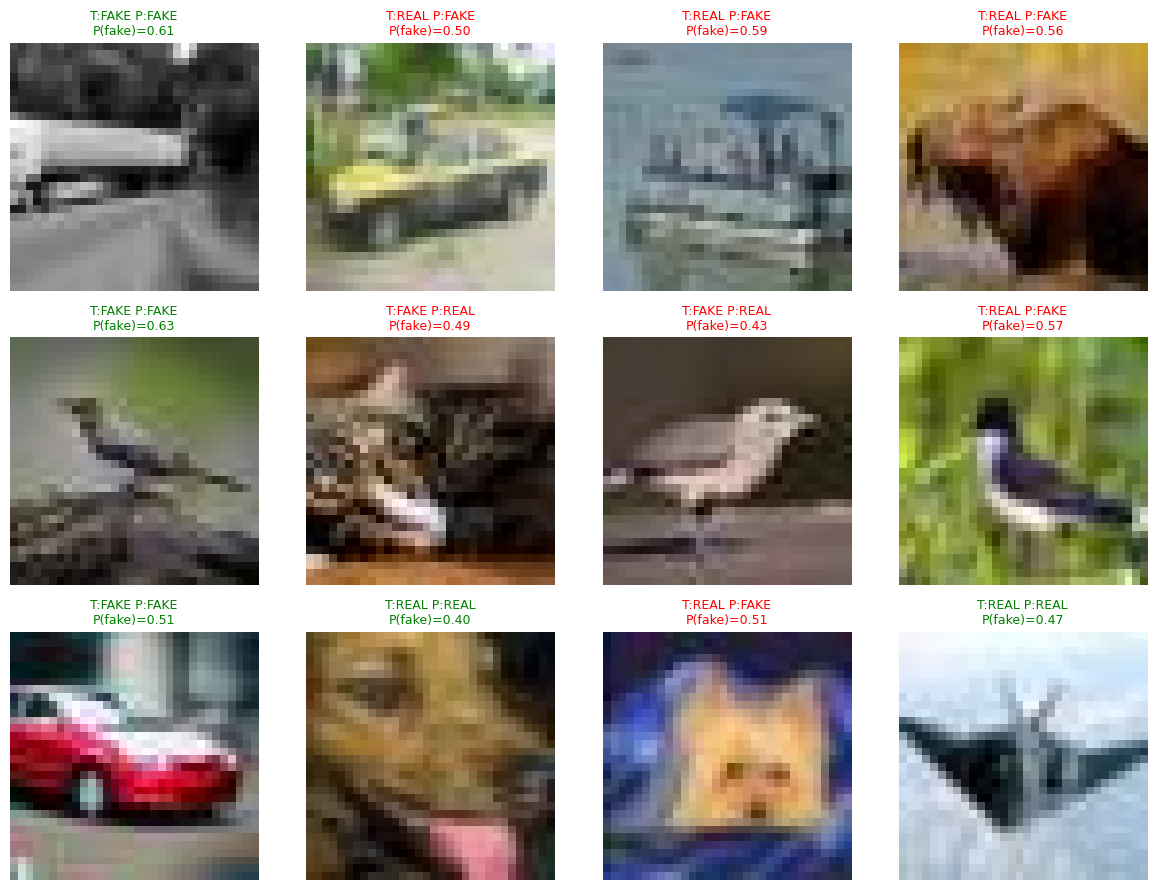

Saved sample prediction grid -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\sample_predictions_grid.png


In [21]:
# Visual sample predictions (for report)
def denormalize(tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

sample_n = 12
sample_idx = np.random.choice(len(test_ds), size=min(sample_n, len(test_ds)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for ax, idx in zip(axes, sample_idx):
    image_t, label, path = test_ds[idx]
    with torch.no_grad():
        logits = model(image_t.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1)[0]
        pred = int(torch.argmax(probs).item())
        p_fake = float(probs[1].item())

    img = denormalize(image_t).permute(1, 2, 0).numpy()
    ax.imshow(img)
    color = 'green' if pred == label else 'red'
    ax.set_title(f"T:{CLASS_NAMES[label]} P:{CLASS_NAMES[pred]}\nP(fake)={p_fake:.2f}", fontsize=9, color=color)
    ax.axis('off')

for j in range(len(sample_idx), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
samples_png = RESULTS_METRICS_DIR / 'sample_predictions_grid.png'
plt.savefig(samples_png, dpi=180)
plt.show()
print(f"Saved sample prediction grid -> {samples_png}")

In [22]:
# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False,
        )

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach()


def overlay_cam(image_rgb, cam, alpha=0.45, cmap='jet'):
    cmap_obj = plt.get_cmap(cmap)
    heat = cmap_obj(cam)[..., :3]
    overlay = (1 - alpha) * image_rgb + alpha * heat
    return np.clip(overlay, 0, 1)

# Usually the final conv block works best for ResNet18
target_layer = model.layer4[-1].conv2
gradcam = GradCAM(model, target_layer)
print('Grad-CAM initialized on layer4[-1].conv2')

Grad-CAM initialized on layer4[-1].conv2


In [23]:
# Generate Grad-CAM heatmaps for sample test images
num_gradcam_samples = 10
chosen_idx = np.random.choice(len(test_ds), size=min(num_gradcam_samples, len(test_ds)), replace=False)

rows = []
for i, idx in enumerate(chosen_idx, start=1):
    image_t, label, path = test_ds[idx]
    input_t = image_t.unsqueeze(0).to(device)

    cam, logits = gradcam.generate(input_t)
    probs = torch.softmax(logits, dim=1)[0]
    pred = int(torch.argmax(probs).item())

    image_rgb = denormalize(image_t).permute(1, 2, 0).numpy()
    overlay = overlay_cam(image_rgb, cam, alpha=0.45, cmap='jet')

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nT:{CLASS_NAMES[label]} P:{CLASS_NAMES[pred]}")
    axes[2].axis('off')

    plt.tight_layout()
    out_path = RESULTS_GRADCAM_DIR / f'gradcam_{i:02d}.png'
    plt.savefig(out_path, dpi=180)
    plt.close(fig)

    rows.append({
        'sample_id': i,
        'path': path,
        'y_true': label,
        'y_pred': pred,
        'p_real': float(probs[0].item()),
        'p_fake': float(probs[1].item()),
        'gradcam_image': str(out_path),
    })

gradcam_df = pd.DataFrame(rows)
gradcam_csv = RESULTS_GRADCAM_DIR / 'gradcam_summary.csv'
gradcam_df.to_csv(gradcam_csv, index=False)

display(gradcam_df.head())
print(f"Saved {len(gradcam_df)} Grad-CAM images -> {RESULTS_GRADCAM_DIR}")
print(f"Saved Grad-CAM summary -> {gradcam_csv}")

,sample_id,path,y_true,y_pred,p_real,p_fake,gradcam_image
0,1,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dat...,1,0,0.532581,0.467419,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Pha...
1,2,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dat...,1,1,0.403927,0.596073,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Pha...
2,3,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dat...,0,0,0.650333,0.349667,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Pha...
3,4,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dat...,1,1,0.457010,0.542990,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Pha...
4,5,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\dat...,0,1,0.493076,0.506924,C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Pha...


Saved 10 Grad-CAM images -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_gradcam
Saved Grad-CAM summary -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_gradcam\gradcam_summary.csv


,checkpoint,epoch,train_loss,train_acc,val_loss,val_acc
0,resnet18_subset_epoch1.pt,1,0.703101,None,0.673754,0.612
1,resnet18_subset_epoch2.pt,2,0.691039,None,0.662141,0.633
2,resnet18_subset_epoch3.pt,3,0.657086,None,0.647884,0.659
3,resnet18_subset_epoch4.pt,4,0.642565,None,0.633980,0.671
4,resnet18_subset_epoch5.pt,5,0.644708,None,0.624442,0.673


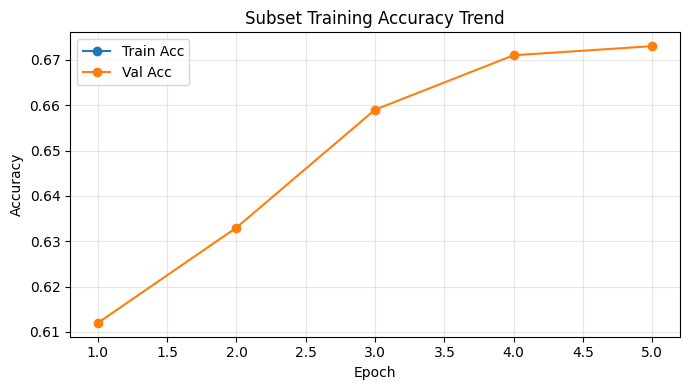

Feedback to M1:
- Best validation accuracy: 0.6730 at epoch 5.
- If train_acc is much higher than val_acc, increase regularization and augmentation.
- If both curves plateau early, unfreeze more backbone layers and lower LR schedule patience.
- Review confusion matrix false positives/false negatives to rebalance augmentation.
Saved training trend table -> C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\subset_training_trend.csv


In [24]:
# Early training analysis for M1 feedback
# Reads checkpoint series (if present) and summarizes validation trend.
series_paths = sorted((PHASE1_DIR / 'models').glob('resnet18_subset_epoch*.pt'))

rows = []
for p in series_paths:
    ckpt = torch.load(p, map_location='cpu')
    if isinstance(ckpt, dict):
        rows.append({
            'checkpoint': p.name,
            'epoch': ckpt.get('epoch', None),
            'train_loss': ckpt.get('train_loss', None),
            'train_acc': ckpt.get('train_acc', None),
            'val_loss': ckpt.get('val_loss', None),
            'val_acc': ckpt.get('val_acc', None),
        })

if rows:
    trend_df = pd.DataFrame(rows).sort_values('epoch')
    trend_csv = RESULTS_METRICS_DIR / 'subset_training_trend.csv'
    trend_df.to_csv(trend_csv, index=False)
    display(trend_df)

    if trend_df['val_acc'].notna().any():
        plt.figure(figsize=(7, 4))
        plt.plot(trend_df['epoch'], trend_df['train_acc'], marker='o', label='Train Acc')
        plt.plot(trend_df['epoch'], trend_df['val_acc'], marker='o', label='Val Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Subset Training Accuracy Trend')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        trend_png = RESULTS_METRICS_DIR / 'subset_training_accuracy_trend.png'
        plt.savefig(trend_png, dpi=180)
        plt.show()

        best_row = trend_df.loc[trend_df['val_acc'].idxmax()]
        print('Feedback to M1:')
        print(f"- Best validation accuracy: {best_row['val_acc']:.4f} at epoch {int(best_row['epoch'])}.")
        print('- If train_acc is much higher than val_acc, increase regularization and augmentation.')
        print('- If both curves plateau early, unfreeze more backbone layers and lower LR schedule patience.')
        print('- Review confusion matrix false positives/false negatives to rebalance augmentation.')
        print(f"Saved training trend table -> {trend_csv}")
    else:
        print('Checkpoint series found, but per-epoch metrics are missing in checkpoint dicts.')
else:
    print('No epoch checkpoint series found for subset trend analysis.')

In [25]:
# Final artifact summary
print('Artifacts created:')
for p in sorted(RESULTS_METRICS_DIR.glob('*')):
    print('metrics :', p)
for p in sorted(RESULTS_GRADCAM_DIR.glob('*')):
    print('gradcam :', p)

# Cleanup hooks when done
gradcam.remove_hooks()

Artifacts created:
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\classification_report.txt
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\confusion_matrix.csv
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\confusion_matrix_heatmap.png
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\metrics_summary.csv
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\sample_predictions_grid.png
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\subset_training_accuracy_trend.png
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\subset_training_trend.csv
metrics : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_metrics\test_predictions.csv
gradcam : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_gradcam\gradcam_01.png
gradcam : C:\Users\Vedha\feb hack\Feb-2026-Hackathon\Phase1\results_gradcam\